# PCA_Gene_Expression
## Principal Component Analysis on Gene Expression Data

This notebook do PCA from scratch on breast cancer gene expression dataset.

**Dataset files needed (put in data/ folder):**
- data/class.tsv — ER status labels (1=ER+, 0=ER-)
- data/columns.tsv.gz — gene ID to gene name mapping
- data/filtered.tsv.gz — gene expression matrix

**What we do:**
1. Load data and extract XBP1, GATA3 expression
2. Implement PCA from scratch using covariance matrix and eigen decomposition
3. Plot Fig 1a: scatter of GATA3 vs XBP1
4. Plot Fig 1b: PC directions on scatter
5. Plot Fig 1c: projection of samples onto PC1


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from io import StringIO

# load class labels — 1 means ER+, 0 means ER-
class_labels = pd.read_csv("C:/Users/ponna/Downloads/class.tsv", sep='	', header=None)
labels = class_labels[0].values

# load gene mapping — maps gene ID to gene symbol name
with gzip.open("C:/Users/ponna/Downloads/columns.tsv.gz", 'rt') as f:
    lines = [line for line in f if not line.startswith('#')]
filtered_content = StringIO(''.join(lines))
gene_mapping = pd.read_csv(filtered_content, sep='	')

# load expression matrix
with gzip.open("C:/Users/ponna/Downloads/filtered.tsv.gz", 'rt') as f:
    expression_data = pd.read_csv(f, sep='	')
expression_data.columns = expression_data.columns.astype(str).str.strip()

print("Labels shape:", labels.shape)
print("ER+ count:", (labels == 1).sum(), "| ER- count:", (labels == 0).sum())
print("Expression matrix shape:", expression_data.shape)
print("Gene mapping shape:", gene_mapping.shape)


Labels shape: (105,)
ER+ count: 45 | ER- count: 60
Expression matrix shape: (105, 16174)
Gene mapping shape: (27648, 16)


In [2]:
# XBP1 gene ID is known as 4404
xbp1_id = 4404

# get GATA3 gene ID from mapping table
gata3_id = gene_mapping[gene_mapping['GeneSymbol'] == 'GATA3']['ID'].values[0]

print("GATA3 gene ID:", gata3_id)
print("XBP1 gene ID:", xbp1_id)
print("XBP1 column exists:", str(xbp1_id) in expression_data.columns)
print("GATA3 column exists:", str(gata3_id) in expression_data.columns)

# extract expression values as numpy array
xbp1_expression = expression_data[str(xbp1_id)].values
gata3_expression = expression_data[str(gata3_id)].values

# color map — red for ER+, black for ER-
colors = ['red' if label == 1 else 'black' for label in labels]

print("XBP1 expression mean (ER+):", np.mean(xbp1_expression[labels == 1]).round(3))
print("XBP1 expression mean (ER-):", np.mean(xbp1_expression[labels == 0]).round(3))


GATA3 gene ID: 4359
XBP1 gene ID: 4404
XBP1 column exists: True
GATA3 column exists: True
XBP1 expression mean (ER+): 2.121
XBP1 expression mean (ER-): 0.561


## PCA Implementation from Scratch

Steps:
1. Center data by subtracting mean of each feature
2. Compute covariance matrix
3. Find eigenvalues and eigenvectors using np.linalg.eigh (for symmetric matrix)
4. Sort by eigenvalue descending (largest variance first)
5. Optionally flip directions so PC1 align with ER+ group


In [3]:
def perform_pca(X, labels=None, k=None):
    # center data first — subtract mean of each column
    x_centered = X - np.mean(X, axis=0)

    # covariance matrix — how features vary together
    cov_matrix = np.cov(x_centered, rowvar=False)

    # eigen decomposition of symmetric covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # sort by eigenvalue descending — largest variance first
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # orient PC1 so ER+ group has higher projection than ER- group
    if labels is not None:
        pc1 = eigenvectors[:, 0]
        proj_pc1 = np.dot(x_centered, pc1)
        if np.mean(proj_pc1[labels == 1]) < np.mean(proj_pc1[labels == 0]):
            eigenvectors[:, 0] *= -1

        # keep coordinate system right-handed
        if eigenvectors.shape[1] >= 2:
            pc1 = eigenvectors[:, 0]
            pc2 = eigenvectors[:, 1]
            cross = np.cross(pc1, pc2)
            if cross < 0:
                eigenvectors[:, 1] *= -1

    # return only top k components if k is given
    if k is not None:
        eigenvectors = eigenvectors[:, :k]
        eigenvalues = eigenvalues[:k]

    return eigenvectors, eigenvalues, x_centered

print("perform_pca function defined")


perform_pca function defined


## Figure 1(a): GATA3 vs XBP1 Gene Expression Scatter

Red = ER+, Black = ER-


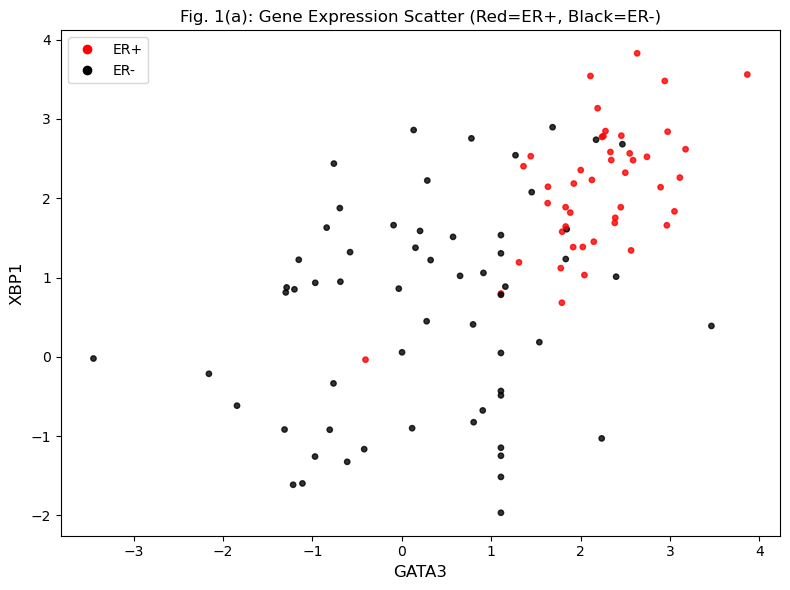

Saved: figure_1a.png


In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors, s=15, alpha=0.8)

plt.xlabel('GATA3', fontsize=12)
plt.ylabel('XBP1', fontsize=12)
plt.title('Fig. 1(a): Gene Expression Scatter (Red=ER+, Black=ER-)', fontsize=12)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='ER+', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', label='ER-', markersize=8)
]
plt.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.savefig('figure_1a.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure_1a.png")


## Figure 1(b): PCA Direction Arrows on Scatter

PC1 and PC2 arrows show direction of maximum variance in the data.


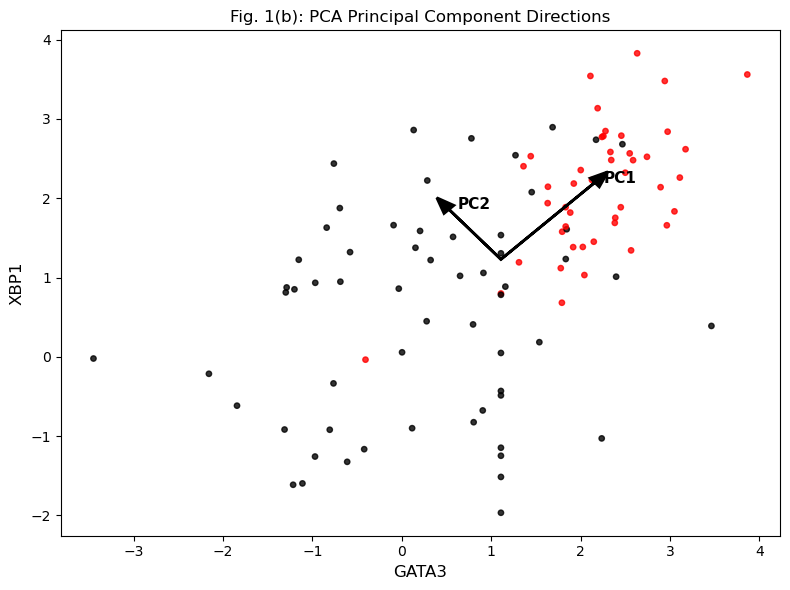

Saved: figure_1b.png


In [5]:
# stack gene expressions into 2D matrix for PCA
X_2d = np.column_stack((gata3_expression, xbp1_expression))
eigenvectors, eigenvalues, x_centered = perform_pca(X_2d, labels=labels)

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

# project all samples onto PC1 and PC2
projection_pc1 = np.dot(x_centered, pc1)
projection_pc2 = np.dot(x_centered, pc2)

mean_gata3 = np.mean(gata3_expression)
mean_xbp1 = np.mean(xbp1_expression)

plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors, s=15, alpha=0.8)

# arrow length scaled by std of data for visibility
scale1 = np.std(gata3_expression)
scale2 = np.std(gata3_expression) * 0.6

plt.arrow(mean_gata3, mean_xbp1, pc1[0]*scale1, pc1[1]*scale1,
          head_width=0.15, head_length=0.2, fc='black', ec='black', linewidth=2)
plt.arrow(mean_gata3, mean_xbp1, pc2[0]*scale2, pc2[1]*scale2,
          head_width=0.15, head_length=0.2, fc='black', ec='black', linewidth=2)

plt.text(mean_gata3 + pc1[0]*scale1 + 0.1, mean_xbp1 + pc1[1]*scale1, 'PC1', fontsize=11, fontweight='bold')
plt.text(mean_gata3 + pc2[0]*scale2 + 0.1, mean_xbp1 + pc2[1]*scale2, 'PC2', fontsize=11, fontweight='bold')

plt.xlabel('GATA3', fontsize=12)
plt.ylabel('XBP1', fontsize=12)
plt.title('Fig. 1(b): PCA Principal Component Directions', fontsize=12)
plt.tight_layout()
plt.savefig('figure_1b.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure_1b.png")


## Figure 1(c): Projection of Samples onto PC1

Three rows: All samples, ER- only, ER+ only.
PC1 should separate ER+ and ER- groups.


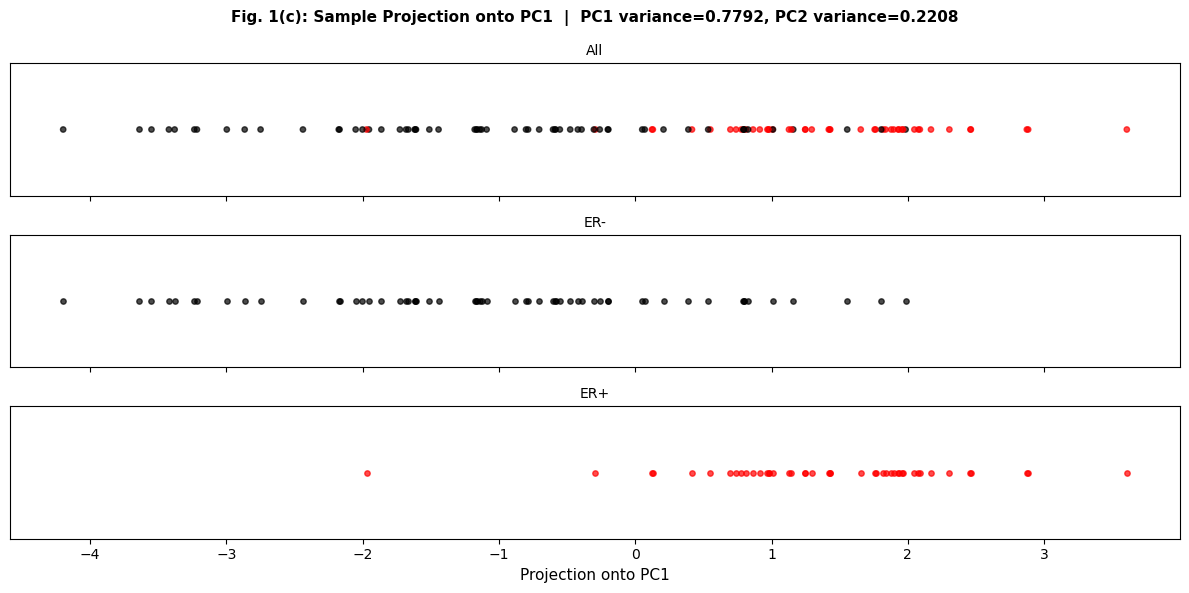

Variance explained by PC1: 0.7792
Variance explained by PC2: 0.2208
Saved: figure_1c.png


In [6]:
# split projections by class
er_pos_pc1 = projection_pc1[labels == 1]
er_neg_pc1 = projection_pc1[labels == 0]

# colors for each sample
colors_all = ['red' if labels[i] == 1 else 'black' for i in range(len(labels))]

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# top: all samples
axes[0].scatter(projection_pc1, np.zeros_like(projection_pc1), c=colors_all, s=15, alpha=0.7)
axes[0].set_yticks([])
axes[0].set_title('All', fontsize=10)

# middle: ER- only in black
axes[1].scatter(er_neg_pc1, np.zeros_like(er_neg_pc1), c='black', s=15, alpha=0.7)
axes[1].set_yticks([])
axes[1].set_title('ER-', fontsize=10)

# bottom: ER+ only in red
axes[2].scatter(er_pos_pc1, np.zeros_like(er_pos_pc1), c='red', s=15, alpha=0.7)
axes[2].set_yticks([])
axes[2].set_title('ER+', fontsize=10)
axes[2].set_xlabel('Projection onto PC1', fontsize=11)

# compute variance explained
var_pc1 = eigenvalues[0] / np.sum(eigenvalues)
var_pc2 = eigenvalues[1] / np.sum(eigenvalues)

fig.suptitle(f'Fig. 1(c): Sample Projection onto PC1  |  PC1 variance={var_pc1:.4f}, PC2 variance={var_pc2:.4f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_1c.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance explained by PC1: {var_pc1:.4f}")
print(f"Variance explained by PC2: {var_pc2:.4f}")
print("Saved: figure_1c.png")


## Summary

- PCA reduce dimensionality by finding directions of maximum variance
- PC1 capture most variance — it separate ER+ from ER- group clearly
- Covariance matrix and eigen decomposition are core of PCA
- Centering data before PCA is important

### Files saved:
- figure_1a.png — GATA3 vs XBP1 scatter
- figure_1b.png — PCA direction arrows
- figure_1c.png — PC1 projection by class
